# WR RNN Improved - GRU varijanta

Mirror `WR_RNN_Improved.ipynb` ali sa GRU umesto LSTM. Cilj: head-to-head poredjenje LSTM vs GRU u istoj hibridnoj arhitekturi.

Dva eksperimenta:
1. Controlled comparison - uzmemo *isti hiperparametar set* kao najbolji LSTM (iz `rnn_improved_results.json`) i samo zamenimo cell na GRU. To je čista A/B ablacija (isti dropout, lr, seq_len, units, sve identično).
2. GRU-optimal Optuna - zatim pustimo Optuna da nadje GRU-specifičan optimum (60 trial-ova, search prostor identičan Improved RNN-u ali sa `rnn_type` fiksiranim na GRU).

Na kraju upoređujemo: LSTM (iz prethodnog notebook-a) vs GRU@LSTM-HPs vs GRU-Optuna-best.


---
## 1. Imports

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import os, json, gc, time, random

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks, optimizers, losses, Model, Input
from tensorflow.keras.layers import (
    LSTM, GRU, Dense, Dropout, Bidirectional,
    LayerNormalization, GaussianNoise,
    Masking, Concatenate
)

import optuna
from optuna_integration.tfkeras import TFKerasPruningCallback
optuna.logging.set_verbosity(optuna.logging.WARNING)

import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 100
matplotlib.rcParams['figure.figsize'] = (14, 5)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'

for gpu in tf.config.list_physical_devices('GPU'):
    tf.config.experimental.set_memory_growth(gpu, True)

print(f'TensorFlow {tf.__version__}')

TensorFlow 2.21.0


---
## 2. Load Existing LSTM Results (for direct comparison)

In [2]:
# Ucitaj rezultate iz Improved RNN notebook-a (LSTM varijante)
from pathlib import Path

results_file_candidates = [
    Path('results/rnn_improved_results.json'),
    Path('../results/rnn_improved_results.json'),
    Path('../../results/rnn_improved_results.json'),
    Path('../../../results/rnn_improved_results.json'),
]

results_file = next((p for p in results_file_candidates if p.exists()), None)
if results_file is None:
    raise FileNotFoundError(
        "Nisam nasao rnn_improved_results.json. Pokreni prethodni notebook ili proveri results folder."
    )

with open(results_file, 'r', encoding='utf-8') as f:
    lstm_results = json.load(f)

lstm_best_params = lstm_results['best_params']
lstm_test = {
    'mae': lstm_results['test_mae'],
    'rmse': lstm_results['test_rmse'],
    'r2': lstm_results['test_r2'],
}

print('=== LSTM (Improved RNN, prethodni notebook) ===')
print(f'  Loaded from: {results_file.resolve()}')
print(f"  Test MAE:  {lstm_test['mae']:.4f}")
print(f"  Test RMSE: {lstm_test['rmse']:.4f}")
print(f"  Test R2:   {lstm_test['r2']:.4f}")
print()
print(f"  Best HPs: {json.dumps(lstm_best_params, indent=2)}")

=== LSTM (Improved RNN, prethodni notebook) ===
  Loaded from: C:\Users\Korisnik\Documents\GitHub\Analiza-i-Obrada\results\rnn_improved_results.json
  Test MAE:  18.0289
  Test RMSE: 25.1101
  Test R2:   0.3354

  Best HPs: {
  "seq_len": 12,
  "batch_size": 32,
  "sw_strength": 0.6,
  "rnn_type": "LSTM",
  "bidirectional": false,
  "n_rnn_layers": 1,
  "dropout": 0.30000000000000004,
  "rnn_dropout": 0.3,
  "noise_stddev": 0.2,
  "huber_delta": 0.5,
  "lr": 0.0003497766177042005,
  "weight_decay": 0.0019053479572860338,
  "rnn_units_0": 128,
  "static_units": 96,
  "dense_units": 64
}


---
## 3. Data Loading & Minimal Feature Engineering

Identično kao u `WR_RNN_Improved.ipynb` - sirove statistike + računamo `team_changed`, `is_new_season`, `weeks_since_last_game`, career averages.

In [3]:
from pathlib import Path

data_file_candidates = [
    Path('data/fully combined/wr_all_weeks.csv'),
    Path('../data/fully combined/wr_all_weeks.csv'),
    Path('../../data/fully combined/wr_all_weeks.csv'),
    Path('../../../data/fully combined/wr_all_weeks.csv'),
]

data_file = next((p for p in data_file_candidates if p.exists()), None)
if data_file is None:
    raise FileNotFoundError(
        'Nisam nasao wr_all_weeks.csv. Proveri da li postoji u data/fully combined/.'
    )

df = pd.read_csv(data_file)
df['week'] = df['game_id'].str.split('_').str[1].astype(int)
df = df.sort_values(['receiver_player_id', 'season', 'week']).reset_index(drop=True)
print(f'Raw data: {df.shape}')
print(f'Loaded from: {data_file.resolve()}')

# Team change
df['player_team_inferred'] = np.where(
    (df['home_team'] == df['defteam']) & (df['away_team'] != df['defteam']),
    df['away_team'],
    np.where(
        (df['away_team'] == df['defteam']) & (df['home_team'] != df['defteam']),
        df['home_team'], np.nan
    )
)
prev_team = df.groupby('receiver_player_id')['player_team_inferred'].shift(1)
df['team_changed'] = (
    df['player_team_inferred'].notna() & prev_team.notna()
    & (df['player_team_inferred'] != prev_team)
).astype(int)

prev_season = df.groupby('receiver_player_id')['season'].shift(1)
df['is_new_season'] = (
    prev_season.notna() & (df['season'] != prev_season)
).astype(int)

df['season_week_abs'] = (df['season'] - 2015) * 22 + df['week']
df['weeks_since_last_game'] = (
    df.groupby('receiver_player_id')['season_week_abs']
    .diff().fillna(1).clip(lower=1).astype(float)
)
df.drop(columns=['season_week_abs'], inplace=True)

# Previous-season career averages
season_career = (
    df.groupby(['receiver_player_id', 'season'], as_index=False)
    .agg(
        avg_yards=('receiving_yards', 'mean'),
        avg_target_share=('target_share', 'mean'),
        avg_epa=('epa', 'mean'),
        avg_air_yard_share=('air_yard_share', 'mean'),
        avg_catch_rate=('catch_rate', 'mean'),
        games_played=('game_id', 'count')
    )
    .sort_values(['receiver_player_id', 'season'])
)
for c in ['avg_yards', 'avg_target_share', 'avg_epa',
          'avg_air_yard_share', 'avg_catch_rate', 'games_played']:
    season_career[f'{c}_last_season'] = (
        season_career.groupby('receiver_player_id')[c].shift(1)
    )
career_cols = [
    'avg_yards_last_season', 'avg_target_share_last_season',
    'avg_epa_last_season', 'avg_air_yard_share_last_season',
    'avg_catch_rate_last_season', 'games_played_last_season',
]
season_career = season_career[['receiver_player_id', 'season'] + career_cols]
df = df.merge(season_career, on=['receiver_player_id', 'season'], how='left')
df[career_cols] = df[career_cols].fillna(0)

print(f'After engineering: {df.shape}')

Raw data: (46115, 100)
Loaded from: C:\Users\Korisnik\Documents\GitHub\Analiza-i-Obrada\data\fully combined\wr_all_weeks.csv
After engineering: (46115, 110)


---
## 4. Feature Groups (identično Improved RNN)

In [10]:
seq_feature_cols = [
    'receiving_yards', 'targets', 'receptions', 'air_yards', 'yac',
    'first_downs', 'tds', 'epa', 'wpa',
    'catch_rate', 'yards_per_target', 'avg_depth', 'adot', 'success_rate',
    'target_share', 'air_yard_share', 'target_share_std', 'reception_std',
    'team_pass_attempts', 'team_air_yards', 'team_epa',
    'qb_completions', 'qb_attempts', 'qb_comp_pct', 'qb_cpoe',
    'avg_score_diff', 'wp_var',
    'yards_Q1', 'yards_Q2', 'yards_Q3',
    'def_yards_dev', 'def_epa_dev',
    'weeks_since_last_game',
]

static_feature_cols = [
    'pregame_spread', 'pregame_total',
    'surface', 'is_dome', 'temp_f', 'humidity_pct', 'wind_mph',
    'is_rain', 'is_snow', 'is_clear',
    'week', 'team_changed', 'is_new_season', 'weeks_since_last_game',
    'avg_yards_last_season', 'avg_target_share_last_season',
    'avg_epa_last_season', 'avg_air_yard_share_last_season',
    'avg_catch_rate_last_season', 'games_played_last_season',
]

n_seq_features = len(seq_feature_cols)
n_static_features = len(static_feature_cols)
print(f'Sequence features per timestep: {n_seq_features}')
print(f'Static features: {n_static_features}')

Sequence features per timestep: 33
Static features: 20


---
## 5. Scale & Build Padded Sequences

In [5]:
train_seasons = list(range(2015, 2022))
val_seasons = [2022, 2023]
test_seasons = [2024, 2025]

df[seq_feature_cols] = df[seq_feature_cols].fillna(0)
df[static_feature_cols] = df[static_feature_cols].fillna(0)

train_mask = df['season'].isin(train_seasons)

seq_scaler = StandardScaler()
seq_scaler.fit(df.loc[train_mask, seq_feature_cols])

static_scaler = StandardScaler()
static_scaler.fit(df.loc[train_mask, static_feature_cols])

df_scaled = df.copy()
df_scaled[seq_feature_cols] = seq_scaler.transform(df[seq_feature_cols])
df_scaled[static_feature_cols] = static_scaler.transform(df[static_feature_cols])
df_scaled['receiving_yards_orig'] = df['receiving_yards'].values

print(f'Scalers fit on {train_mask.sum()} training rows')

Scalers fit on 30583 training rows


In [6]:
MAX_SEQ_LEN = 12
SEQ_LENGTHS = [6, 8, 12]

def build_padded_career_sequences(df_scaled, seq_features, static_features, seq_len):
    X_seq, X_static, y_sqrt, y_orig, seasons = [], [], [], [], []
    for pid, group in df_scaled.groupby('receiver_player_id'):
        group = group.sort_values(['season', 'week'])
        n = len(group)
        if n < 2:
            continue
        seq_vals = group[seq_features].values
        static_vals = group[static_features].values
        yards = group['receiving_yards_orig'].values
        season_vals = group['season'].values
        for t in range(1, n):
            start = max(0, t - seq_len)
            past = seq_vals[start:t]
            actual_len = past.shape[0]
            if actual_len < seq_len:
                padding = np.zeros((seq_len - actual_len, len(seq_features)))
                past = np.vstack([padding, past])
            X_seq.append(past)
            X_static.append(static_vals[t])
            y_sqrt.append(np.sqrt(max(yards[t], 0)))
            y_orig.append(yards[t])
            seasons.append(season_vals[t])
    return (
        np.array(X_seq, dtype=np.float32),
        np.array(X_static, dtype=np.float32),
        np.array(y_sqrt, dtype=np.float32),
        np.array(y_orig, dtype=np.float32),
        np.array(seasons),
    )

print(f'Building sequences for max seq_len={MAX_SEQ_LEN}...')
t0 = time.time()
X_seq_all, X_static_all, y_sqrt_all, y_orig_all, seasons_all = build_padded_career_sequences(
    df_scaled, seq_feature_cols, static_feature_cols, MAX_SEQ_LEN)
print(f'Built {len(X_seq_all)} sequences in {time.time()-t0:.1f}s')
print(f'X_seq shape: {X_seq_all.shape}')

Building sequences for max seq_len=12...
Built 44396 sequences in 1.8s
X_seq shape: (44396, 12, 33)


In [7]:
tr_mask = np.isin(seasons_all, train_seasons)
va_mask = np.isin(seasons_all, val_seasons)
te_mask = np.isin(seasons_all, test_seasons)

seq_data = {}
for sl in SEQ_LENGTHS:
    X_seq_sl = X_seq_all[:, -sl:, :]
    seq_data[sl] = {
        'train': (X_seq_sl[tr_mask], X_static_all[tr_mask],
                  y_sqrt_all[tr_mask], y_orig_all[tr_mask]),
        'val':   (X_seq_sl[va_mask], X_static_all[va_mask],
                  y_sqrt_all[va_mask], y_orig_all[va_mask]),
        'test':  (X_seq_sl[te_mask], X_static_all[te_mask],
                  y_sqrt_all[te_mask], y_orig_all[te_mask]),
    }
    print(f'seq_len={sl:>2d}  |  train={tr_mask.sum()}  val={va_mask.sum()}  test={te_mask.sum()}')

seq_len= 6  |  train=29276  val=8921  test=6199
seq_len= 8  |  train=29276  val=8921  test=6199
seq_len=12  |  train=29276  val=8921  test=6199


---
## 6. Helpers

In [8]:
def evaluate_model(y_true_orig, y_pred_sqrt):
    y_pred_orig = np.clip(y_pred_sqrt, 0, None) ** 2
    mae = mean_absolute_error(y_true_orig, y_pred_orig)
    rmse = np.sqrt(mean_squared_error(y_true_orig, y_pred_orig))
    r2 = r2_score(y_true_orig, y_pred_orig)
    return mae, rmse, r2, y_pred_orig

def make_weights(strength, y_orig):
    mean_y = np.mean(np.clip(y_orig, 0, None))
    base = np.sqrt(np.clip(y_orig, 0, None) / mean_y)
    return 1.0 + strength * base

def get_final_metrics(hist):
    best_epoch = int(np.argmin(hist.history['val_loss']))
    return {
        'Best Epoch': best_epoch + 1,
        'Train Loss': float(hist.history['loss'][best_epoch]),
        'Val Loss': float(hist.history['val_loss'][best_epoch]),
        'Loss Gap': float(hist.history['val_loss'][best_epoch] - hist.history['loss'][best_epoch]),
        'Train MAE (sqrt)': float(hist.history['mae'][best_epoch]),
        'Val MAE (sqrt)': float(hist.history['val_mae'][best_epoch]),
    }

print('Helpers ready.')

Helpers ready.


---
## 7. Dual-Input GRU Architecture (fixed-HP builder)

Identična arhitektura kao Improved RNN, ali GRU je zaključan i hiperparametri se prosleđuju kao dict (umesto preko Optuna trial-a).

In [9]:
def build_gru_fixed(params, seq_len, n_seq_feat, n_static_feat):
    bidirectional = params.get('bidirectional', False)
    n_rnn_layers = params['n_rnn_layers']
    dropout = params['dropout']
    rnn_dropout = params['rnn_dropout']
    noise_stddev = params['noise_stddev']
    huber_delta = params['huber_delta']
    lr = params['lr']
    wd = params['weight_decay']

    seq_input = Input(shape=(seq_len, n_seq_feat), name='seq_input')
    x = Masking(mask_value=0.0)(seq_input)

    for i in range(n_rnn_layers):
        units = params[f'rnn_units_{i}']
        return_seq = (i < n_rnn_layers - 1)
        rnn_layer = GRU(units, return_sequences=return_seq,
                        dropout=rnn_dropout, recurrent_dropout=rnn_dropout)
        if bidirectional:
            x = Bidirectional(rnn_layer)(x)
        else:
            x = rnn_layer(x)
        x = LayerNormalization()(x)
        x = Dropout(dropout)(x)

    static_input = Input(shape=(n_static_feat,), name='static_input')
    s = GaussianNoise(noise_stddev)(static_input)
    s = Dense(params['static_units'], activation='relu')(s)
    s = LayerNormalization()(s)
    s = Dropout(dropout)(s)

    merged = Concatenate()([x, s])
    merged = Dense(params['dense_units'], activation='relu')(merged)
    merged = LayerNormalization()(merged)
    merged = Dropout(dropout * 0.5)(merged)
    output = Dense(1)(merged)

    model = Model(inputs=[seq_input, static_input], outputs=output)
    opt = optimizers.AdamW(learning_rate=lr, weight_decay=wd)
    model.compile(optimizer=opt, loss=losses.Huber(delta=huber_delta), metrics=['mae'])
    return model

print('Fixed-HP GRU builder ready.')

Fixed-HP GRU builder ready.


---
## 8. Eksperiment 1 - Controlled comparison: GRU sa LSTM-ovim hiperparametrima

Uzimamo identične hyperparametre kao najbolji LSTM, samo zamenjujemo cell. Ovo je čista ablacija "samo cell type se promenio".

In [10]:
print('=== Eksperiment 1: GRU @ LSTM-best HPs ===')
print(f'Using HPs from LSTM Improved RNN best trial:')
for k, v in lstm_best_params.items():
    print(f'  {k}: {v}')

tf.keras.backend.clear_session()
tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

bp = lstm_best_params
seq_len_e1 = bp['seq_len']

data = seq_data[seq_len_e1]
X_seq_tr, X_static_tr, y_tr_sqrt, y_tr_orig = data['train']
X_seq_va, X_static_va, y_va_sqrt, y_va_orig = data['val']
X_seq_te, X_static_te, y_te_sqrt, y_te_orig = data['test']

sw = make_weights(bp['sw_strength'], y_tr_orig)

model_e1 = build_gru_fixed(bp, seq_len_e1, n_seq_features, n_static_features)
model_e1.summary()

cb_e1 = [
    callbacks.ModelCheckpoint('rnn_gru_e1_best.keras', monitor='val_loss',
                              save_best_only=True, verbose=0),
    callbacks.EarlyStopping(monitor='val_loss', patience=30,
                            restore_best_weights=True, min_delta=1e-4),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=10, min_lr=1e-6),
]

t0 = time.time()
history_e1 = model_e1.fit(
    [X_seq_tr, X_static_tr], y_tr_sqrt,
    sample_weight=sw,
    validation_data=([X_seq_va, X_static_va], y_va_sqrt),
    epochs=500, batch_size=bp['batch_size'],
    callbacks=cb_e1, verbose=1,
)
print(f'\nE1 trained in {time.time()-t0:.0f}s')

mae_e1, rmse_e1, r2_e1, _ = evaluate_model(
    y_te_orig, model_e1.predict([X_seq_te, X_static_te], verbose=0).flatten()
)
metrics_e1 = get_final_metrics(history_e1)
print(f'\nGRU @ LSTM HPs | MAE={mae_e1:.2f}  RMSE={rmse_e1:.2f}  R2={r2_e1:.4f}')
print(f'  best_epoch={metrics_e1["Best Epoch"]}  loss_gap={metrics_e1["Loss Gap"]:.4f}')

=== Eksperiment 1: GRU @ LSTM-best HPs ===
Using HPs from LSTM Improved RNN best trial:
  seq_len: 12
  batch_size: 32
  sw_strength: 0.6
  rnn_type: LSTM
  bidirectional: False
  n_rnn_layers: 1
  dropout: 0.30000000000000004
  rnn_dropout: 0.3
  noise_stddev: 0.2
  huber_delta: 0.5
  lr: 0.0003497766177042005
  weight_decay: 0.0019053479572860338
  rnn_units_0: 128
  static_units: 96
  dense_units: 64



Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ seq_input           │ (None, 12, 33)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 12, 33)    │          0 │ seq_input[0][0]   │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ static_input        │ (None, 20)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ masking (Masking)   │ (None, 12, 33)    │          0 │ seq_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ any (Any)           │ (None, 12)        │          0 │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gaussian_noise      │ (None, 20)        │          0 │ static_input[0][… │
│ (GaussianNoise)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru (GRU)           │ (None, 128)       │     62,592 │ masking[0][0],    │
│                     │                   │            │ any[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 96)        │      2,016 │ gaussian_noise[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 128)       │        256 │ gru[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 96)        │        192 │ dense[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 96)        │          0 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 224)       │          0 │ dropout[0][0],    │
│ (Concatenate)       │                   │            │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │     14,400 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 64)        │        128 │ dense_1[0][0]     │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64)        │          0 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 1)         │         65 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 79,649 (311.13 KB)

 Trainable params: 79,649 (311.13 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/500
915/915 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 1.4778 - mae: 2.2094 - val_loss: 0.9060 - val_mae: 2.0489 - learning_rate: 3.4978e-04
Epoch 2/500
915/915 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 1.3459 - mae: 2.0646 - val_loss: 0.8825 - val_mae: 2.0017 - learning_rate: 3.4978e-04
Epoch 3/500
915/915 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 1.3265 - mae: 2.0433 - val_loss: 0.8788 - val_mae: 1.9938 - learning_rate: 3.4978e-04
Epoch 4/500
915/915 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 1.3181 - mae: 2.0311 - val_loss: 0.8800 - val_mae: 1.9964 - learning_rate: 3.4978e-04
Epoch 5/500
915/915 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 1.3171 - mae: 2.0325 - val_loss: 0.8719 - val_mae: 1.9804 - learning_rate: 3.4978e-04
Epoch 6/500
915/915 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 1.3072 - mae: 2.0193 - val_loss: 0.8747 - val_mae: 1.9858 - learning_rate: 3.4978e-04
Epoch 7/500
915/915 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 1.3041 - mae: 2.0151 - val_loss: 0.8679 - val_mae: 1.9724

---
## 9. Eksperiment 2 - Optuna search za GRU (60 trial-ova)

Identičan search prostor kao Improved RNN, ali `rnn_type` je fiksiran na GRU. Manje trial-ova jer je prostor manji (jedna kategorička dimenzija manje) i znamo da je TPE već konvergirao za sličan setup.

In [11]:
def create_gru_model(trial, seq_len, n_seq_feat, n_static_feat):
    bidirectional = trial.suggest_categorical('bidirectional', [True, False])
    n_rnn_layers = trial.suggest_int('n_rnn_layers', 1, 2)
    dropout = trial.suggest_float('dropout', 0.2, 0.4, step=0.05)
    rnn_dropout = trial.suggest_float('rnn_dropout', 0.1, 0.3, step=0.1)
    noise_stddev = trial.suggest_float('noise_stddev', 0.1, 0.3, step=0.05)
    huber_delta = trial.suggest_float('huber_delta', 0.5, 2.0, step=0.5)
    lr = trial.suggest_float('lr', 5e-5, 3e-3, log=True)
    wd = trial.suggest_float('weight_decay', 1e-4, 5e-3, log=True)

    seq_input = Input(shape=(seq_len, n_seq_feat), name='seq_input')
    x = Masking(mask_value=0.0)(seq_input)

    for i in range(n_rnn_layers):
        units = trial.suggest_int(f'rnn_units_{i}', 64, 192, step=64)
        return_seq = (i < n_rnn_layers - 1)
        rnn_layer = GRU(units, return_sequences=return_seq,
                        dropout=rnn_dropout, recurrent_dropout=rnn_dropout)
        if bidirectional:
            x = Bidirectional(rnn_layer)(x)
        else:
            x = rnn_layer(x)
        x = LayerNormalization()(x)
        x = Dropout(dropout)(x)

    static_input = Input(shape=(n_static_feat,), name='static_input')
    s = GaussianNoise(noise_stddev)(static_input)
    static_units = trial.suggest_int('static_units', 32, 96, step=32)
    s = Dense(static_units, activation='relu')(s)
    s = LayerNormalization()(s)
    s = Dropout(dropout)(s)

    merged = Concatenate()([x, s])
    dense_units = trial.suggest_int('dense_units', 64, 128, step=32)
    merged = Dense(dense_units, activation='relu')(merged)
    merged = LayerNormalization()(merged)
    merged = Dropout(dropout * 0.5)(merged)
    output = Dense(1)(merged)

    model = Model(inputs=[seq_input, static_input], outputs=output)
    opt = optimizers.AdamW(learning_rate=lr, weight_decay=wd)
    model.compile(optimizer=opt, loss=losses.Huber(delta=huber_delta), metrics=['mae'])
    return model

print('GRU-only model builder ready.')

GRU-only model builder ready.


In [12]:
def objective_gru(trial):
    tf.keras.backend.clear_session()

    seq_len = trial.suggest_categorical('seq_len', SEQ_LENGTHS)
    batch_size = trial.suggest_categorical('batch_size', [32, 64])
    sw_strength = trial.suggest_float('sw_strength', 0.5, 1.0, step=0.1)

    data = seq_data[seq_len]
    X_seq_tr, X_static_tr, y_tr_sqrt, y_tr_orig = data['train']
    X_seq_va, X_static_va, y_va_sqrt, y_va_orig = data['val']

    sw = make_weights(sw_strength, y_tr_orig)
    model = create_gru_model(trial, seq_len, n_seq_features, n_static_features)

    cb = [
        callbacks.EarlyStopping(monitor='val_loss', patience=12,
                                restore_best_weights=True, min_delta=1e-4),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=5, min_lr=1e-6),
        TFKerasPruningCallback(trial, 'val_loss'),
    ]

    model.fit(
        [X_seq_tr, X_static_tr], y_tr_sqrt,
        sample_weight=sw,
        validation_data=([X_seq_va, X_static_va], y_va_sqrt),
        epochs=150, batch_size=batch_size,
        callbacks=cb, verbose=0,
    )

    val_pred = model.predict([X_seq_va, X_static_va], verbose=0).flatten()
    val_pred_orig = np.clip(val_pred, 0, None) ** 2
    return float(np.sqrt(mean_squared_error(y_va_orig, val_pred_orig)))

print('Objective defined.')

Objective defined.


In [13]:
gru_study = optuna.create_study(
    direction='minimize',
    study_name='rnn_gru_only',
    pruner=optuna.pruners.MedianPruner(n_startup_trials=8, n_warmup_steps=10),
    sampler=optuna.samplers.TPESampler(seed=SEED),
)

print('Starting GRU-only Optuna optimization (60 trials)...')
print('Search: 1-2 layers, max 192 units, GRU only')
print('This will take ~2-3 hours on CPU.\n')

gru_study.optimize(objective_gru, n_trials=60, show_progress_bar=True)

print(f'\nBest GRU trial:')
print(f'  Val RMSE: {gru_study.best_value:.4f}')
print(f'  Params: {json.dumps(gru_study.best_params, indent=2)}')

Starting GRU-only Optuna optimization (60 trials)...
Search: 1-2 layers, max 192 units, GRU only
This will take ~2-3 hours on CPU.



Best trial: 5. Best value: 25.4135: 100%|██████████| 60/60 [1:28:28<00:00, 88.48s/it] 


Best GRU trial:
  Val RMSE: 25.4135
  Params: {
  "seq_len": 12,
  "batch_size": 64,
  "sw_strength": 0.7,
  "bidirectional": false,
  "n_rnn_layers": 1,
  "dropout": 0.35000000000000003,
  "rnn_dropout": 0.1,
  "noise_stddev": 0.2,
  "huber_delta": 2.0,
  "lr": 0.00013875520816523183,
  "weight_decay": 0.0004979987773685088,
  "rnn_units_0": 192,
  "static_units": 32,
  "dense_units": 64
}


---
## 10. Train Best GRU (Optuna optimum) with extended epochs

In [14]:
print('=== Eksperiment 2: GRU Optuna-best ===')
tf.keras.backend.clear_session()
tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

gp = gru_study.best_params
best_seq_len_gru = gp['seq_len']
best_trial_gru = gru_study.best_trial

data = seq_data[best_seq_len_gru]
X_seq_tr, X_static_tr, y_tr_sqrt, y_tr_orig = data['train']
X_seq_va, X_static_va, y_va_sqrt, y_va_orig = data['val']
X_seq_te, X_static_te, y_te_sqrt, y_te_orig = data['test']

sw = make_weights(gp['sw_strength'], y_tr_orig)

model_e2 = create_gru_model(best_trial_gru, best_seq_len_gru, n_seq_features, n_static_features)
model_e2.summary()

cb_e2 = [
    callbacks.ModelCheckpoint('rnn_gru_e2_best.keras', monitor='val_loss',
                              save_best_only=True, verbose=0),
    callbacks.EarlyStopping(monitor='val_loss', patience=30,
                            restore_best_weights=True, min_delta=1e-4),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=10, min_lr=1e-6),
]

t0 = time.time()
history_e2 = model_e2.fit(
    [X_seq_tr, X_static_tr], y_tr_sqrt,
    sample_weight=sw,
    validation_data=([X_seq_va, X_static_va], y_va_sqrt),
    epochs=500, batch_size=gp['batch_size'],
    callbacks=cb_e2, verbose=1,
)
print(f'\nE2 trained in {time.time()-t0:.0f}s')

mae_e2, rmse_e2, r2_e2, _ = evaluate_model(
    y_te_orig, model_e2.predict([X_seq_te, X_static_te], verbose=0).flatten()
)
metrics_e2 = get_final_metrics(history_e2)
print(f'\nGRU Optuna-best | MAE={mae_e2:.2f}  RMSE={rmse_e2:.2f}  R2={r2_e2:.4f}')
print(f'  best_epoch={metrics_e2["Best Epoch"]}  loss_gap={metrics_e2["Loss Gap"]:.4f}')

=== Eksperiment 2: GRU Optuna-best ===


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ seq_input           │ (None, 12, 33)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 12, 33)    │          0 │ seq_input[0][0]   │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ static_input        │ (None, 20)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ masking (Masking)   │ (None, 12, 33)    │          0 │ seq_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ any (Any)           │ (None, 12)        │          0 │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gaussian_noise      │ (None, 20)        │          0 │ static_input[0][… │
│ (GaussianNoise)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru (GRU)           │ (None, 192)       │    130,752 │ masking[0][0],    │
│                     │                   │            │ any[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 32)        │        672 │ gaussian_noise[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 192)       │        384 │ gru[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 32)        │         64 │ dense[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 192)       │          0 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 32)        │          0 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 224)       │          0 │ dropout[0][0],    │
│ (Concatenate)       │                   │            │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │     14,400 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 64)        │        128 │ dense_1[0][0]     │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64)        │          0 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 1)         │         65 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 146,465 (572.13 KB)

 Trainable params: 146,465 (572.13 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/500
458/458 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 5.2349 - mae: 2.4030 - val_loss: 2.7277 - val_mae: 2.1694 - learning_rate: 1.3876e-04
Epoch 2/500
458/458 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 4.0502 - mae: 2.1170 - val_loss: 2.6034 - val_mae: 2.1004 - learning_rate: 1.3876e-04
Epoch 3/500
458/458 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 3.9633 - mae: 2.0907 - val_loss: 2.5142 - val_mae: 2.0527 - learning_rate: 1.3876e-04
Epoch 4/500
458/458 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 3.8904 - mae: 2.0696 - val_loss: 2.4655 - val_mae: 2.0253 - learning_rate: 1.3876e-04
Epoch 5/500
458/458 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 3.8654 - mae: 2.0573 - val_loss: 2.4582 - val_mae: 2.0210 - learning_rate: 1.3876e-04
Epoch 6/500
458/458 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 3.8351 - mae: 2.0491 - val_loss: 2.4184 - val_mae: 1.9985 - learning_rate: 1.3876e-04
Epoch 7/500
458/458 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 3.8104 - mae: 2.0402 - val_loss: 2.4085 - val_mae: 1.9927

---
## 11. Optuna Diagnostics

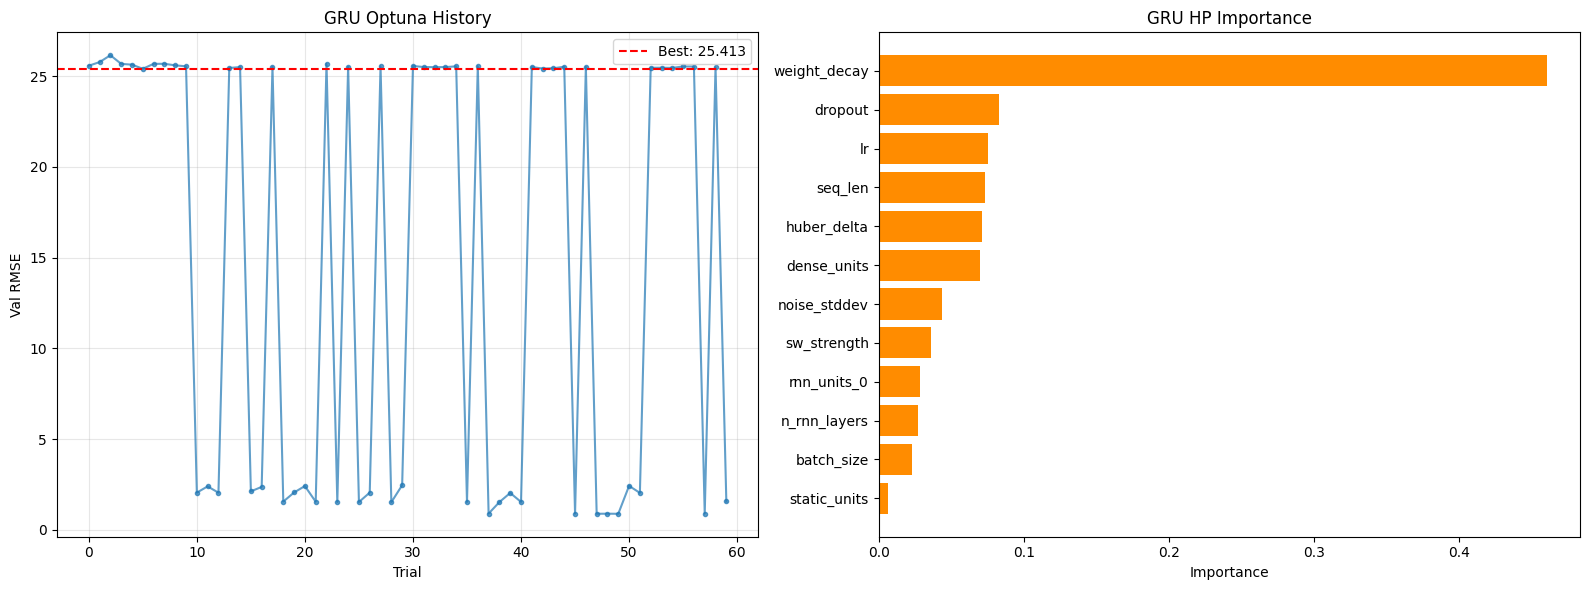

In [15]:
from optuna.importance import get_param_importances

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
vals = [t.value for t in gru_study.trials if t.value is not None]
ax.plot(vals, 'o-', markersize=3, alpha=0.7)
ax.axhline(y=gru_study.best_value, color='r', linestyle='--',
           label=f'Best: {gru_study.best_value:.3f}')
ax.set_xlabel('Trial'); ax.set_ylabel('Val RMSE')
ax.set_title('GRU Optuna History'); ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1]
try:
    imp = get_param_importances(gru_study)
    top = dict(list(imp.items())[:12])
    ax.barh(list(top.keys())[::-1], list(top.values())[::-1], color='darkorange')
    ax.set_title('GRU HP Importance'); ax.set_xlabel('Importance')
except Exception as e:
    ax.text(0.5, 0.5, str(e), transform=ax.transAxes, ha='center')

plt.tight_layout()
plt.savefig('../results/rnn_gru_optuna_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 12. Learning Curves - oba GRU eksperimenta

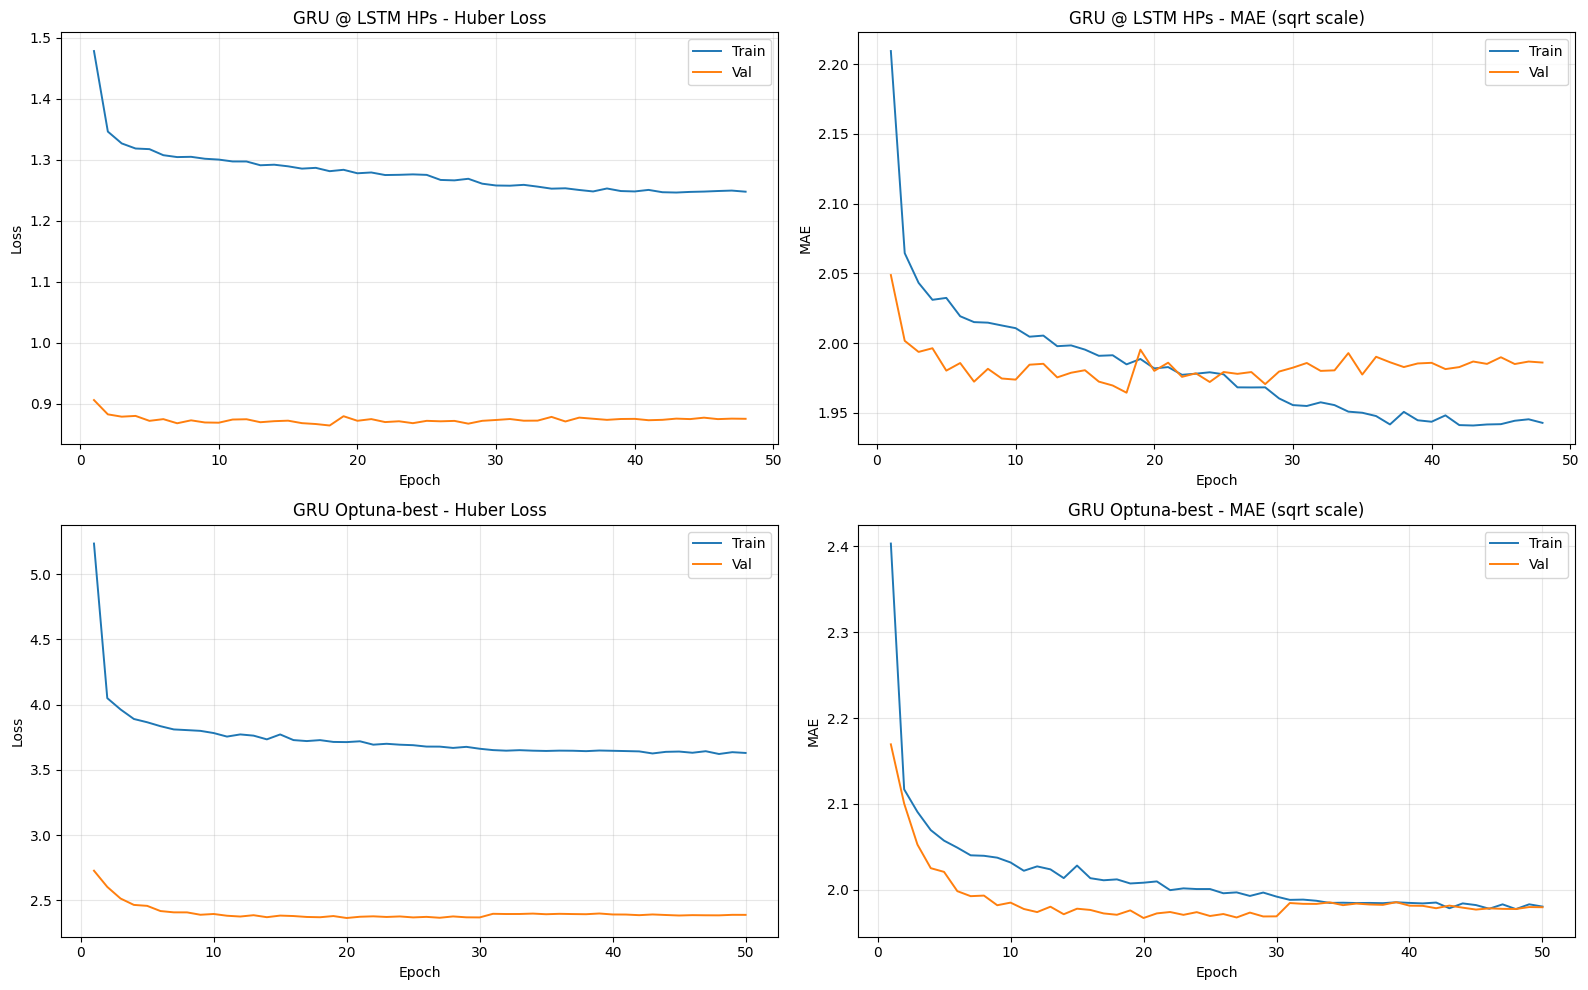

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for row, (hist, label) in enumerate([(history_e1, 'GRU @ LSTM HPs'),
                                      (history_e2, 'GRU Optuna-best')]):
    ep = range(1, len(hist.history['loss']) + 1)
    ax = axes[row, 0]
    ax.plot(ep, hist.history['loss'], label='Train', linewidth=1.4)
    ax.plot(ep, hist.history['val_loss'], label='Val', linewidth=1.4)
    ax.set_title(f'{label} - Huber Loss')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
    ax.legend(); ax.grid(True, alpha=0.3)

    ax = axes[row, 1]
    ax.plot(ep, hist.history['mae'], label='Train', linewidth=1.4)
    ax.plot(ep, hist.history['val_mae'], label='Val', linewidth=1.4)
    ax.set_title(f'{label} - MAE (sqrt scale)')
    ax.set_xlabel('Epoch'); ax.set_ylabel('MAE')
    ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../results/rnn_gru_learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 13. Head-to-head Comparison: LSTM vs GRU

In [17]:
compare = pd.DataFrame([
    {
        'Model': 'LSTM Optuna-best (Improved RNN)',
        'Cell': 'LSTM',
        'Test MAE': lstm_test['mae'],
        'Test RMSE': lstm_test['rmse'],
        'Test R2': lstm_test['r2'],
        'Source': 'rnn_improved_results.json',
    },
    {
        'Model': 'GRU @ LSTM HPs (controlled)',
        'Cell': 'GRU',
        'Test MAE': round(mae_e1, 4),
        'Test RMSE': round(rmse_e1, 4),
        'Test R2': round(r2_e1, 4),
        'Source': 'this notebook (E1)',
    },
    {
        'Model': 'GRU Optuna-best',
        'Cell': 'GRU',
        'Test MAE': round(mae_e2, 4),
        'Test RMSE': round(rmse_e2, 4),
        'Test R2': round(r2_e2, 4),
        'Source': 'this notebook (E2)',
    },
]).sort_values('Test R2', ascending=False).reset_index(drop=True)

print('\n' + '='*80)
print('LSTM vs GRU - Head-to-Head Comparison')
print('='*80)
print(compare.to_string(index=False))
print('='*80)

print('\n--- GRU @ LSTM HPs vs LSTM (controlled ablation) ---')
print(f'  MAE delta:  {mae_e1 - lstm_test["mae"]:+.4f}')
print(f'  RMSE delta: {rmse_e1 - lstm_test["rmse"]:+.4f}')
print(f'  R2 delta:   {r2_e1 - lstm_test["r2"]:+.4f}')

print('\n--- GRU Optuna-best vs LSTM Optuna-best (each its own optimum) ---')
print(f'  MAE delta:  {mae_e2 - lstm_test["mae"]:+.4f}')
print(f'  RMSE delta: {rmse_e2 - lstm_test["rmse"]:+.4f}')
print(f'  R2 delta:   {r2_e2 - lstm_test["r2"]:+.4f}')


LSTM vs GRU - Head-to-Head Comparison
                          Model Cell  Test MAE  Test RMSE  Test R2                    Source
LSTM Optuna-best (Improved RNN) LSTM   18.0289    25.1101   0.3354 rnn_improved_results.json
    GRU @ LSTM HPs (controlled)  GRU   18.1360    25.1289   0.3344        this notebook (E1)
                GRU Optuna-best  GRU   18.0943    25.1642   0.3326        this notebook (E2)

--- GRU @ LSTM HPs vs LSTM (controlled ablation) ---
  MAE delta:  +0.1071
  RMSE delta: +0.0188
  R2 delta:   -0.0010

--- GRU Optuna-best vs LSTM Optuna-best (each its own optimum) ---
  MAE delta:  +0.0654
  RMSE delta: +0.0541
  R2 delta:   -0.0028


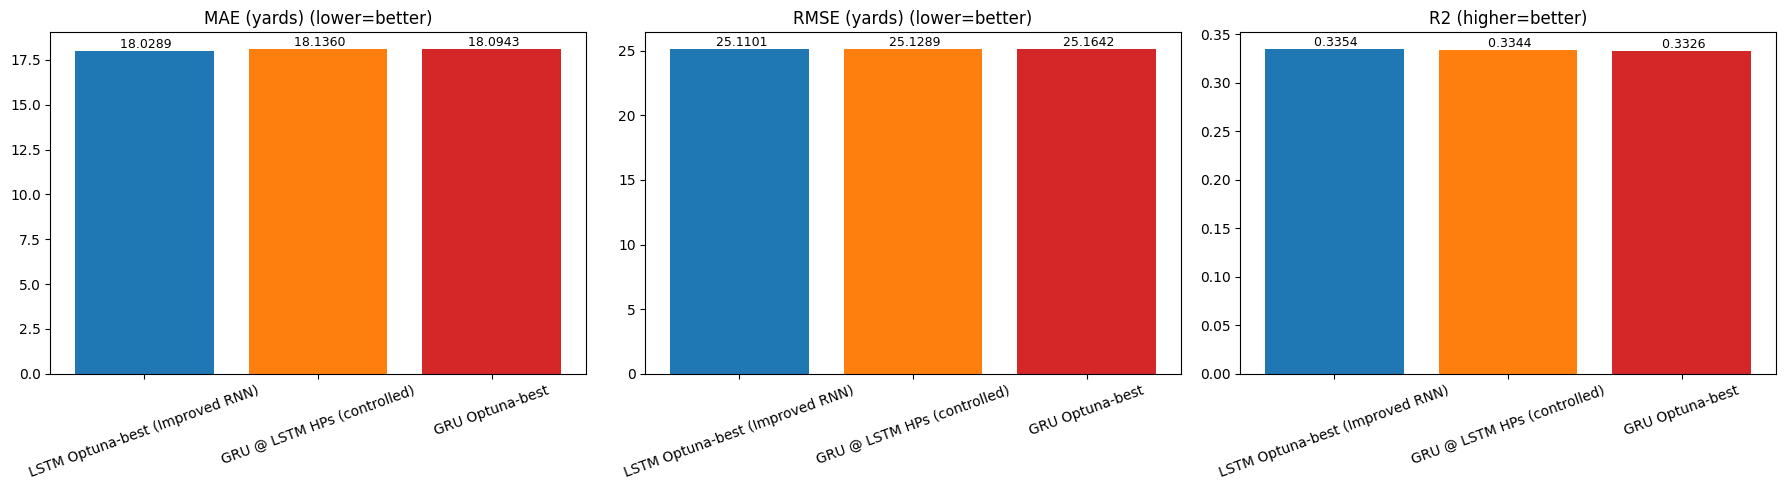

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metrics = [('Test MAE', 'MAE (yards)', 'lower=better'),
           ('Test RMSE', 'RMSE (yards)', 'lower=better'),
           ('Test R2', 'R2', 'higher=better')]

colors = ['#1f77b4', '#ff7f0e', '#d62728']
for ax, (col, title, hint) in zip(axes, metrics):
    vals = compare[col].astype(float).values
    ax.bar(compare['Model'], vals, color=colors[:len(compare)])
    ax.set_title(f'{title} ({hint})')
    ax.tick_params(axis='x', rotation=20)
    for i, v in enumerate(vals):
        ax.text(i, v, f' {v:.4f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('../results/rnn_gru_vs_lstm_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 14. Save Results

In [19]:
output = {
    'lstm_reference': {
        'best_params': lstm_best_params,
        'test_mae': lstm_test['mae'],
        'test_rmse': lstm_test['rmse'],
        'test_r2': lstm_test['r2'],
    },
    'gru_at_lstm_hps': {
        'used_params': lstm_best_params,
        'test_mae': round(mae_e1, 4),
        'test_rmse': round(rmse_e1, 4),
        'test_r2': round(r2_e1, 4),
        'training_metrics': metrics_e1,
    },
    'gru_optuna_best': {
        'best_params': gru_study.best_params,
        'best_val_rmse': gru_study.best_value,
        'test_mae': round(mae_e2, 4),
        'test_rmse': round(rmse_e2, 4),
        'test_r2': round(r2_e2, 4),
        'training_metrics': metrics_e2,
    },
    'seq_features': seq_feature_cols,
    'static_features': static_feature_cols,
}

with open('../results/rnn_gru_results.json', 'w') as f:
    json.dump(output, f, indent=2, default=str)

compare.to_csv('../results/rnn_gru_vs_lstm.csv', index=False)

print('Saved:')
print('  results/rnn_gru_results.json')
print('  results/rnn_gru_vs_lstm.csv')

print(f'\n=== DONE ===')
print(f'LSTM (ref):       MAE={lstm_test["mae"]:.2f}  RMSE={lstm_test["rmse"]:.2f}  R2={lstm_test["r2"]:.4f}')
print(f'GRU @ LSTM HPs:   MAE={mae_e1:.2f}  RMSE={rmse_e1:.2f}  R2={r2_e1:.4f}')
print(f'GRU Optuna-best:  MAE={mae_e2:.2f}  RMSE={rmse_e2:.2f}  R2={r2_e2:.4f}')

Saved:
  results/rnn_gru_results.json
  results/rnn_gru_vs_lstm.csv

=== DONE ===
LSTM (ref):       MAE=18.03  RMSE=25.11  R2=0.3354
GRU @ LSTM HPs:   MAE=18.14  RMSE=25.13  R2=0.3344
GRU Optuna-best:  MAE=18.09  RMSE=25.16  R2=0.3326
